# FBA analysis 

In [2]:
import cobra
from scipy.io import loadmat

In [3]:
tumor_path   = "/Users/valentinreateguirangel/Documents/MATLAB/MyProject/COBRA_project/cobratoolbox/tumorModel.mat"
healthy_path = "/Users/valentinreateguirangel/Documents/MATLAB/MyProject/COBRA_project/cobratoolbox/healthyModel.mat"

### Loading Tumor model 

In [5]:
# Load the MATLAB .mat model
from cobra.io import load_matlab_model

tumor_model = load_matlab_model(
    tumor_path,
    variable_name="tumorModel"   
)

### Loading Healthy model 

In [7]:
# Load the MATLAB .mat model
from cobra.io import load_matlab_model

healthy_model = load_matlab_model(
    healthy_path,
    variable_name="healthyModel"   
)

### Cheking for biomass reaction ID in both models 

In [9]:
# Tumor
# List every reaction that still has a non-zero objective coefficient
c_rxns = [r for r in tumor_model.reactions if r.objective_coefficient != 0]
print("Objective-flagged reactions:", c_rxns)
# If this prints an empty list, no objective is set.

# Search reaction *names* as well as IDs
hit = [r.id for r in tumor_model.reactions if 'biomass' in r.name.lower()]
print("Reactions whose *name* contains 'biomass':", hit)

# Healhty
# List every reaction that still has a non-zero objective coefficient
c_rxns = [r for r in healthy_model.reactions if r.objective_coefficient != 0]
print("Objective-flagged reactions:", c_rxns)
# If this prints an empty list, no objective is set.

# Search reaction *names* as well as IDs
hit = [r.id for r in healthy_model.reactions if 'biomass' in r.name.lower()]
print("Reactions whose *name* contains 'biomass':", hit)

Objective-flagged reactions: [<Reaction MAR13082 at 0x3143b5f10>]
Reactions whose *name* contains 'biomass': ['MAR10024', 'MAR10062', 'MAR10063', 'MAR10064', 'MAR10065', 'MAR13082']
Objective-flagged reactions: [<Reaction MAR13082 at 0x3198c2f00>]
Reactions whose *name* contains 'biomass': ['MAR10024', 'MAR10062', 'MAR10063', 'MAR10064', 'MAR10065', 'MAR13082']


### Loading full model to extract biomass_human and push it back to the models 

In [11]:
from cobra.io import read_sbml_model

full_model = read_sbml_model("/Users/valentinreateguirangel/Downloads/Human-GEM-1.19.0/model/Human-GEM.xml")

In [12]:
# List all biomass term contained in GEM model 
biomass_rxns = [rxn for rxn in full_model.reactions 
                if 'biomass' in rxn.id.lower() or 'biomass' in rxn.name.lower()]
for rxn in biomass_rxns:
    print(rxn.id, ":", rxn.name)

MAR04413 : Generic Human Biomass Reaction
MAR09931 : Biomass maintenance reaction without replication precursors
MAR09932 : Biomass maintenance reaction without replication, transcription, and translation precursors
MAR12140 : HMR Biomass Renal Cancer Reaction
MAR10024 : Exchange of biomass
MAR10062 : Protein pool for biomass reaction
MAR10063 : Lipid pool for biomass reaction
MAR10064 : Small metabolite pool for biomass reaction
MAR10065 : Cofactors and vitamins pool for biomass reaction
MAR13082 : Generic human cell biomass reaction


In [13]:
# Biomass reaction = MAR13082
biomass_rxn = full_model.reactions.get_by_id("MAR13082")

### Check availability of precursor for Biomass

In [15]:
# Extract precursors 
precursors = [
    met for met, coeff in biomass_rxn.metabolites.items() if coeff < 0
]

In [16]:
# Missing Biomass precursors in Tumor for MAR13082
missing = []
for met in precursors:
    try:
        tumor_model.metabolites.get_by_id(met.id)
    except KeyError:
        missing.append(met)


print(f"Biomass precursors in MAR13082: {len(precursors)}")
print(f"Missing from tumor model: {len(missing)}")

for met in missing[:10]:  
    print(f"❌ {met.id:<20} → {met.name}")

present = [met for met in precursors if met.id not in {m.id for m in missing}]
for met in present[:50]:
    print(f"✔️  {met.id:<20} → {met.name}")

Biomass precursors in MAR13082: 9
Missing from tumor model: 0
✔️  MAM01371c            → ATP
✔️  MAM01721n            → DNA
✔️  MAM02040c            → H2O
✔️  MAM02847c            → RNA
✔️  MAM03161c            → glycogen
✔️  MAM10012c            → cofactor_pool_biomass
✔️  MAM10013c            → protein_pool_biomass
✔️  MAM10014c            → lipid_pool_biomass
✔️  MAM10015c            → metabolite_pool_biomass


In [17]:
# Missing Biomass precursors in Healthy for MAR13082
missing = []
for met in precursors:
    try:
        healthy_model.metabolites.get_by_id(met.id)
    except KeyError:
        missing.append(met)


print(f"Biomass precursors in MAR13082: {len(precursors)}")
print(f"Missing from Healthy model: {len(missing)}")

for met in missing[:10]:  
    print(f"❌ {met.id:<20} → {met.name}")

present = [met for met in precursors if met.id not in {m.id for m in missing}]
for met in present[:50]:
    print(f"✔️  {met.id:<20} → {met.name}")

Biomass precursors in MAR13082: 9
Missing from Healthy model: 0
✔️  MAM01371c            → ATP
✔️  MAM01721n            → DNA
✔️  MAM02040c            → H2O
✔️  MAM02847c            → RNA
✔️  MAM03161c            → glycogen
✔️  MAM10012c            → cofactor_pool_biomass
✔️  MAM10013c            → protein_pool_biomass
✔️  MAM10014c            → lipid_pool_biomass
✔️  MAM10015c            → metabolite_pool_biomass


## Testing Biomass flux 

In [19]:
tumor_model.objective = "MAR13082"
solution = tumor_model.optimize()

if solution.status == 'optimal':
    print(f" Tumor model grows — biomass = {solution.objective_value:.4f}")
else:
    print("❌ Model still doesn’t grow ")

 Tumor model grows — biomass = 124.8680


In [20]:
tumor_model.objective = "MAR13082"
solution = healthy_model.optimize()

if solution.status == 'optimal':
    print(f" Healhty model grows — biomass = {solution.objective_value:.4f}")
else:
    print("❌ Model still doesn’t grow ")

 Healhty model grows — biomass = 124.8681


### FBA

In [22]:
# Tumor
tumor_solution = tumor_model.optimize()
print("Biomass flux =", tumor_solution.objective_value)

Biomass flux = 124.86796394598798


In [23]:
# Healhty
healthy_solution = healthy_model.optimize()
print("Biomass flux =", healthy_solution.objective_value)

Biomass flux = 124.86814837744566


## Flux Data Exploration, Top difference flux

In [25]:
import pandas as pd 

# Comparing fluxes
flux_df = (
    pd.DataFrame({"tumor": tumor_solution.fluxes,
                  "healthy": healthy_solution.fluxes})
      .dropna()
)
flux_df["Δ"]  = flux_df["tumor"] - flux_df["healthy"]
flux_df["|Δ|"]= flux_df["Δ"].abs()

In [26]:
# Mapping of reaction ID to reaction name 
id_to_name = {rxn.id: rxn.name for rxn in tumor_model.reactions}

# Add a new column with reaction names
flux_df["reaction_name"] = flux_df.index.map(id_to_name)

# Reorder columns to make it readable
flux_df = flux_df[["reaction_name", "tumor", "healthy", "Δ", "|Δ|"]]

# View top flux changes with names
#flux_df.sort_values("|Δ|", ascending=False).head(50)

# Importing top 500 reactions
flux_df_sorted = flux_df.sort_values("|Δ|", ascending=False)
flux_df_sorted.to_csv("top_500_flux_changes.csv")

### Flux Reactions, Tumor vs Healthy

In [28]:
# Get the flux values from the solution
flux_tumor_series = tumor_solution.fluxes
flux_healthy_series = healthy_solution.fluxes

# Check absolute values against a small threshold (e.g. 1e-6) as common tolerance in metabolic modeling 
is_zero_t = flux_tumor_series.abs() < 1e-6
is_zero_h = flux_healthy_series.abs() < 1e-6

In [29]:
# Count how many are zero or nearly for Tumor flux
zero_count = is_zero_t.sum()
nonzero_count = (~is_zero_t).sum()
total_count = len(flux_tumor_series)

print(f"Total reactions in Tumor flux: {total_count}")
print(f"Zero-flux reactions Tumor flux: {zero_count}")
print(f"Active (non-zero) reactions Tumor flux: {nonzero_count}")

Total reactions in Tumor flux: 9902
Zero-flux reactions Tumor flux: 9075
Active (non-zero) reactions Tumor flux: 827


In [30]:
# Count how many are zero or nearly for Healthy flux
zero_count = is_zero_h.sum()
nonzero_count = (~is_zero_h).sum()
total_count = len(flux_healthy_series)

print(f"Total reactions in Healthy flux: {total_count}")
print(f"Zero-flux reactions Healthy flux: {zero_count}")
print(f"Active (non-zero) reactions Healthy flux: {nonzero_count}")

Total reactions in Healthy flux: 9776
Zero-flux reactions Healthy flux: 8481
Active (non-zero) reactions Healthy flux: 1295


In [31]:
# Non-zero healthy reactions containing key word
active_healthy_fluxes = flux_healthy_series[~is_zero_h]

active_healthy_df = pd.DataFrame({
    "reaction_id": active_healthy_fluxes.index,
    "flux": active_healthy_fluxes.values,
    "reaction_name": [healthy_model.reactions.get_by_id(rid).name for rid in active_healthy_fluxes.index]
})

active_healthy_df["|flux|"] = active_healthy_df["flux"].abs()
active_healthy_df = active_healthy_df.sort_values(by="|flux|", ascending=False)

glucose_related_h = active_healthy_df[active_healthy_df["reaction_name"].str.lower().str.contains("gluc")]
print (glucose_related_h)

     reaction_id        flux  \
7       MAR04381  134.685358   
9       MAR04396 -134.449900   
910     MAR09461  133.918611   
10      MAR08585  133.918611   
143     MAR04524    3.139435   
1068    MAR09830   -1.994830   
1201    MAR11424    1.994830   
921     MAR00090   -1.223782   
1187    MAR11321   -1.223782   
144     MAR04527    1.139435   
181     MAR04767    0.613180   
920     MAR00089    0.613180   
879     MAR09271   -0.613180   
11      MAR03944    0.531289   
22      MAR04304    0.005155   
31      MAR08653    0.005155   
993     MAR01820   -0.002577   

                                          reaction_name      |flux|  
7         D-glucose-6-phosphate aldose-ketose-isomerase  134.685358  
9                     alpha-D-glucose 1,6-phosphomutase  134.449900  
910                Exchange of glucose-1,6-bisphosphate  133.918611  
10    3-phospho-D-glyceroyl-phosphate:alpha-D-glucos...  133.918611  
143     ATP:N-acetyl-D-glucosamine 6-phosphotransferase    3.139435  
106

In [32]:
# Non-zero tumor reactions containing key word
active_tumor_fluxes = flux_tumor_series[~is_zero_t]

active_tumor_df = pd.DataFrame({
    "reaction_id": active_tumor_fluxes.index,
    "flux": active_tumor_fluxes.values,
    "reaction_name": [tumor_model.reactions.get_by_id(rid).name for rid in active_tumor_fluxes.index]
})

active_tumor_df["|flux|"] = active_tumor_df["flux"].abs()
active_tumor_df = active_tumor_df.sort_values(by="|flux|", ascending=False)

glucose_related_t = active_tumor_df[active_tumor_df["reaction_name"].str.lower().str.contains("gluc")]
print (glucose_related_t)

    reaction_id      flux                                      reaction_name  \
94     MAR04527  1.569715                 N-acetyl-D-glucosamine 2-epimerase   
93     MAR04524  1.569715    ATP:N-acetyl-D-glucosamine 6-phosphotransferase   
92     MAR04159  1.569715             UDP-N-acetyl-D-glucosamine 4-epimerase   
11     MAR04131  0.531288  UDP-glucose:alpha-D-galactose-1-phosphate urid...   
10     MAR04396 -0.531288                  alpha-D-glucose 1,6-phosphomutase   
607    MAR00090 -0.043971                  Glucuronidated Compound Transport   
753    MAR11321 -0.043971  UDP-Glucuronosyltransferase 1-10 Precursor, Cy...   
8      MAR04381 -0.036224      D-glucose-6-phosphate aldose-ketose-isomerase   
133    MAR04767  0.023274  bilirubin-glucuronoside:bilirubin-glucuronosid...   
580    MAR09271 -0.023274             Exchange of bilirubin-bisglucuronoside   
606    MAR00089  0.023274                  Glucuronidated Compound Transport   
22     MAR08653  0.012901        D-gluco

## Creating a small subnetwork for each model 

### Picking a Reaction from the list 

In [35]:
target_reaction = "MAR04524"
reaction_name = "D-glucose-6-phosphate:NADP+ 1-oxidoreductase"

### Gathering Metabolites 

In [37]:
reaction = tumor_model.reactions.get_by_id(target_reaction)

In [38]:
# Split into reactants and products 
reactants =[m for m, coeff in reaction.metabolites.items() if coeff < 0] 
products  =[m for m, coeff in reaction.metabolites.items() if coeff > 0]

In [39]:
# Print reactants
print("Reactants:")
for m in reactants:
    print(f"  {m.id: <20} → {m.name}")

# Print products
print("\nProducts:")
for m in products:
    print(f"  {m.id: <20} → {m.name}")

Reactants:
  MAM01371c            → ATP
  MAM02527c            → N-acetylglucosamine

Products:
  MAM01285c            → ADP
  MAM02039c            → H+
  MAM02529c            → N-acetylglucosamine-6-phosphate


In [40]:
tumor_solution.fluxes[target_reaction]

1.5697151747650149

In [41]:
healthy_solution.fluxes[target_reaction]

3.139434986505738

### Small network of target Reaction

#### Healthy and Tumor single graph

In [44]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_reaction_graph(model, solution, reaction_id, reaction_name="Target Reaction", title_prefix="Model"):
    # Get the reaction object
    reaction = model.reactions.get_by_id(reaction_id)

    # Split metabolites
    reactants = [m for m, coeff in reaction.metabolites.items() if coeff < 0]
    products  = [m for m, coeff in reaction.metabolites.items() if coeff > 0]

    # Get flux value
    flux = solution.fluxes[reaction_id]

    # Create graph
    G = nx.DiGraph()
    for m in reactants + products:
        G.add_node(m.id, label=m.name)

    for r in reactants:
        for p in products:
            G.add_edge(r.id, p.id, reaction=reaction_id, flux=flux)

    # Node colors by role
    node_colors = []
    for node in G.nodes():
        if node in [m.id for m in reactants]:
            node_colors.append("salmon")
        elif node in [m.id for m in products]:
            node_colors.append("lightgreen")
        else:
            node_colors.append("skyblue")

    # Edge labels and thickness
    labels = nx.get_node_attributes(G, 'label')
    edge_labels = {
        (u, v): f"{G[u][v]['reaction']} (flux={G[u][v]['flux']:.2f})"
        for u, v in G.edges()
    }
    edge_widths = [max(G[u][v]['flux'], 0.1) for u, v in G.edges()]

    # Draw graph
    pos = nx.spring_layout(G, seed=1)
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, labels=labels, with_labels=True, node_color=node_colors,
            node_size=2000, font_size=10, arrows=True, width=edge_widths)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="darkgreen")
    
    # Optional: add full reaction string
    rxn_str = reaction.reaction
    plt.title(f"{title_prefix}: {reaction_name}\n{rxn_str}", fontsize=10)
    plt.axis("off")
    plt.show()

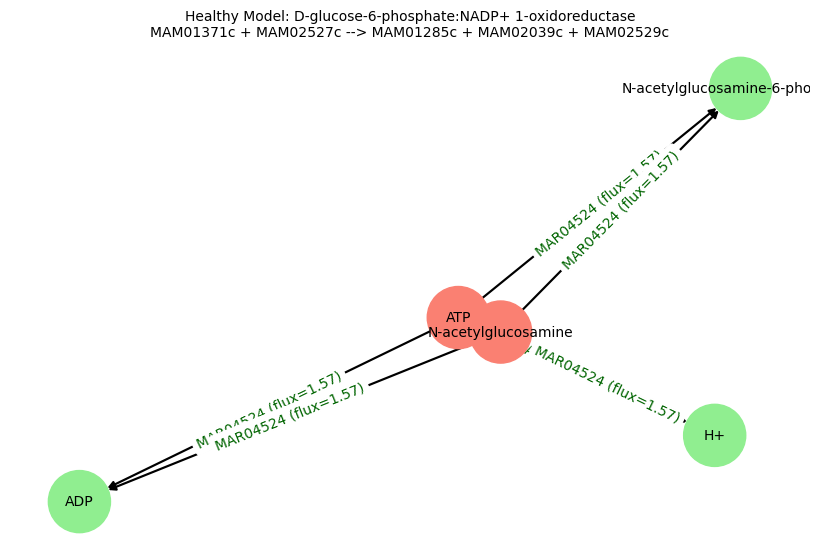

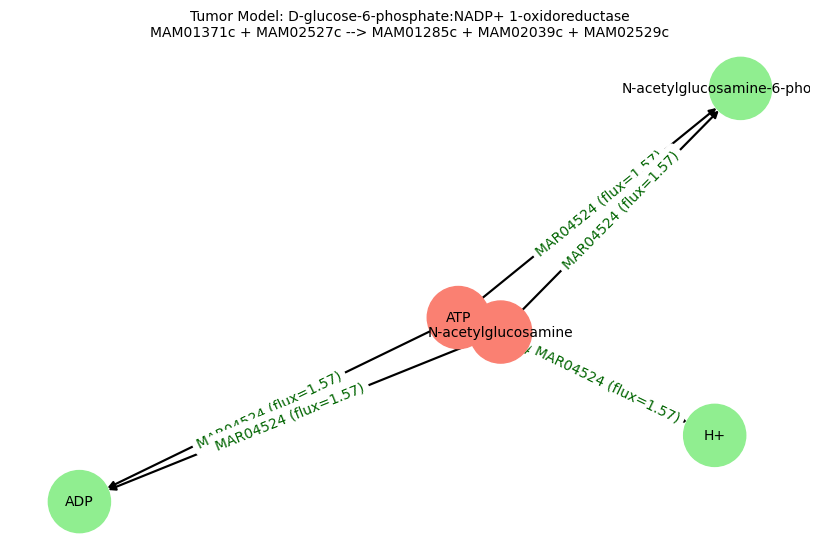

In [45]:

draw_reaction_graph(tumor_model, tumor_solution, target_reaction, reaction_name, title_prefix="Healthy Model")
draw_reaction_graph(tumor_model, tumor_solution, target_reaction, reaction_name, title_prefix="Tumor Model")

### Target drug graph and all 1-hop neighbor reactions, Red = reactants, Green = products 

In [47]:
# Metabolic Network centered on D-glucose-6-phosphaet, includes all metabolites involve in the target reaction 
# and all 1-hop (directly connected to target reaction sharing 1 metabolite) neighbor reactions that use any of its products as reactands, Red = reactants, Green = products

import networkx as nx
import matplotlib.pyplot as plt


def draw_minimal_reaction_graph(model, solution, target_reaction_id, reaction_name="Target Reaction", title_prefix="Model"):
    target_reaction = model.reactions.get_by_id(target_reaction_id)
    G = nx.DiGraph()
    seen_reactions = set([target_reaction_id])

    def add_reaction(reaction):
        flux = solution.fluxes.get(reaction.id, 0.0)
        reactants = [m for m, c in reaction.metabolites.items() if c < 0]
        products  = [m for m, c in reaction.metabolites.items() if c > 0]
        for m in reactants + products:
            G.add_node(m.id, label=m.name)
        for r in reactants:
            for p in products:
                G.add_edge(r.id, p.id, flux=flux)

    # Add main reaction
    add_reaction(target_reaction)

    # Add neighbors (1 hop)
    target_products = [m for m, c in target_reaction.metabolites.items() if c > 0]
    for m in target_products:
        for rxn in model.reactions:
            if rxn.id not in seen_reactions and m in rxn.reactants:
                add_reaction(rxn)
                seen_reactions.add(rxn.id)

    # Layout and visual setup
    pos = nx.spring_layout(G, seed=1)
    edge_widths = [min(5, max(abs(G[u][v]["flux"]), 0.1)) for u, v in G.edges()]
    node_colors = []
    all_reactants = [m for r in seen_reactions for m in model.reactions.get_by_id(r).reactants]
    all_products = [m for r in seen_reactions for m in model.reactions.get_by_id(r).products]

    for node in G.nodes():
        if node in [m.id for m in all_reactants]:
            node_colors.append("salmon")
        elif node in [m.id for m in all_products]:
            node_colors.append("lightgreen")
        else:
            node_colors.append("grey")

    # Optional: show tiny or no labels
    labels = nx.get_node_attributes(G, "label")
    labels = {k: v[:10] for k, v in labels.items()}  # shorten

    # Draw minimalist plot
    plt.figure(figsize=(12, 8))
    nx.draw(
        G, pos,
        node_color=node_colors,
        node_size=20,  # very small dots
        arrows=True,
        width=edge_widths,
        with_labels=False
    )

    plt.title(f"{title_prefix}: {reaction_name}\n{target_reaction.reaction}", fontsize=10)
    plt.axis("off")
    plt.show()

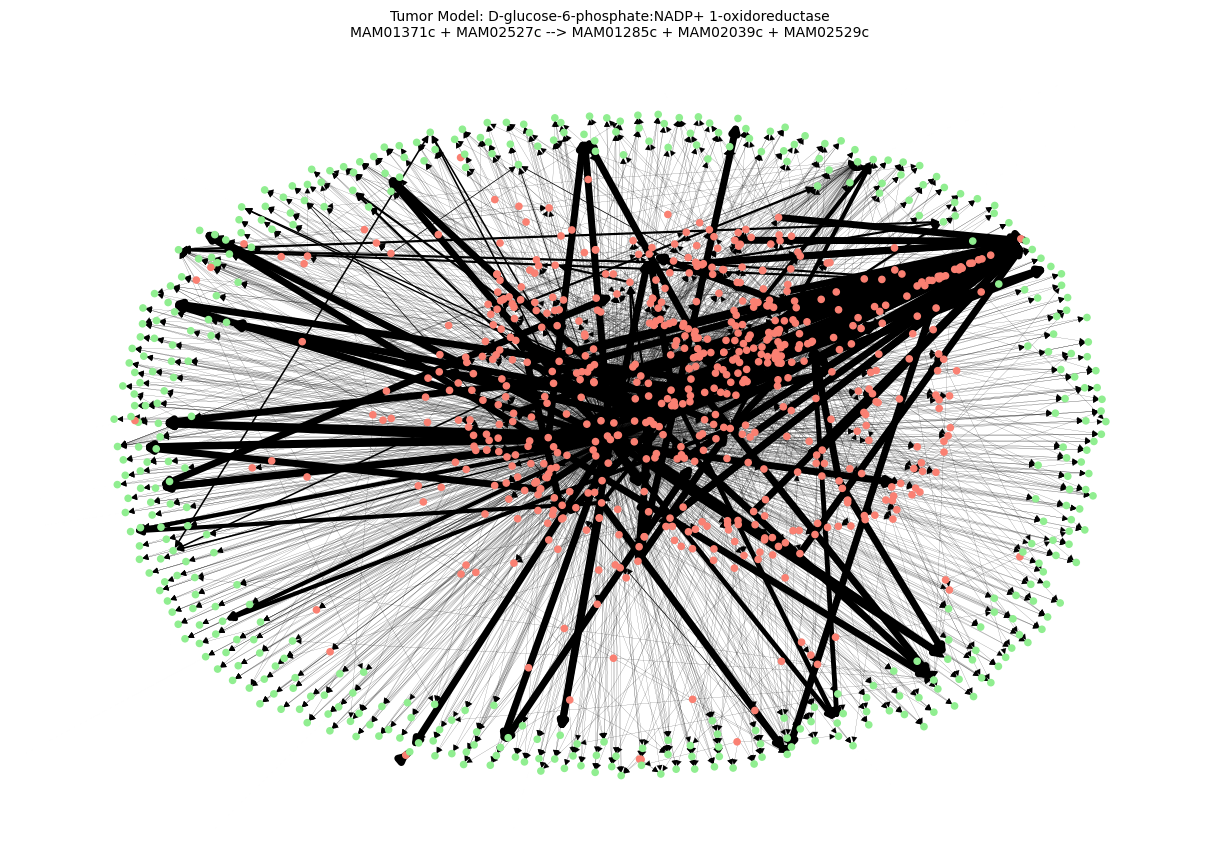

In [48]:
# Tumor Model
draw_minimal_reaction_graph(
    tumor_model,
    tumor_solution,
    target_reaction,
    reaction_name,
    title_prefix="Tumor Model"
)

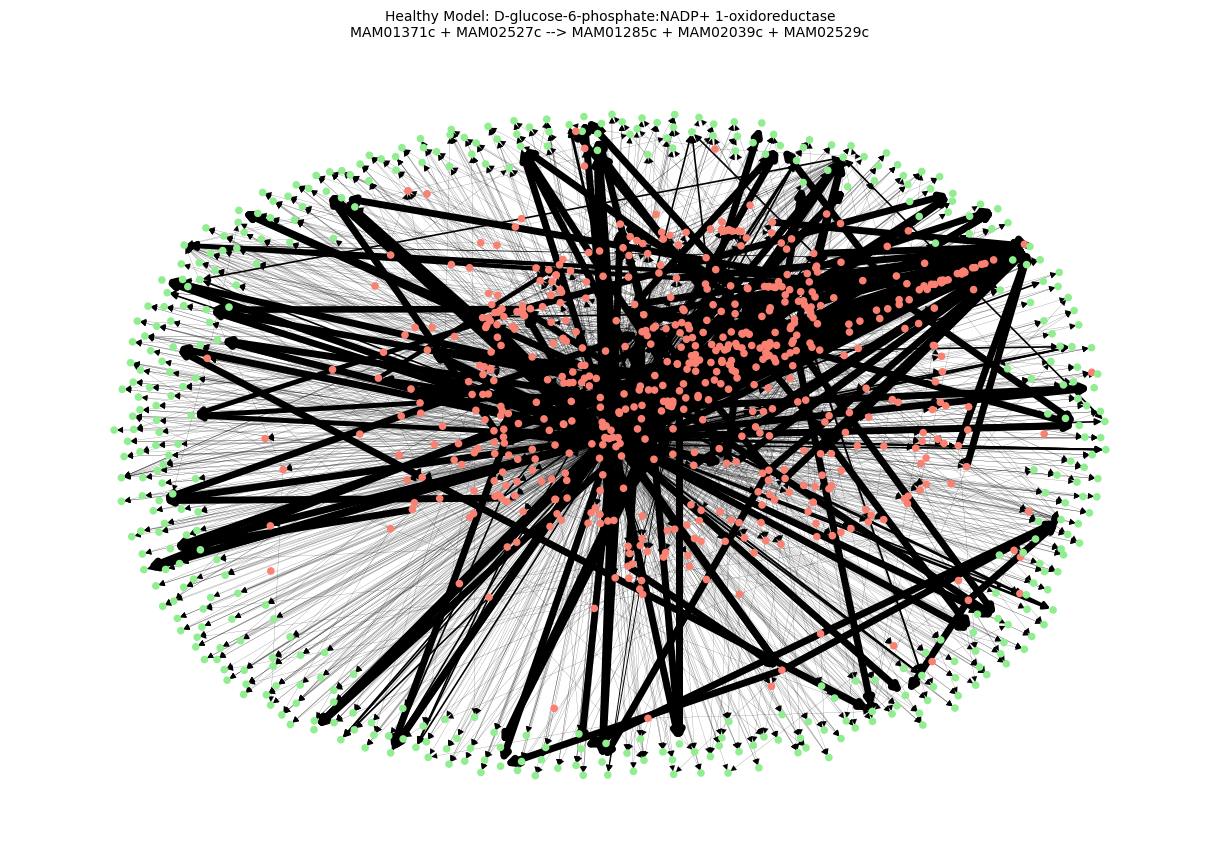

In [49]:
# Healthy Model
draw_minimal_reaction_graph(
    healthy_model,
    healthy_solution,
    target_reaction,
    reaction_name,
    title_prefix="Healthy Model"
)

## Mapping 4 Key Reactions in the top 500 difference flux

### ATP:dUMP phosphotransferase

TP:dTMP phosphotransferase (EC 2.7.4.9) is involved in pyrimidine nucleotide biosynthesis. A large positive ΔFlux in tumor vs healthy suggests elevated dTDP production, potentially linked to increased DNA synthesis and tumor proliferation. Reaction: ATP:dTMP phosphotransferase, Pathway: Pyrimidine metabolism (map00240)

In [53]:
# Reaction 1
target_rxn_id = "MAR03968"

# Get reactions from both models
t_reaction = tumor_model.reactions.get_by_id(target_rxn_id)
h_reaction = healthy_model.reactions.get_by_id(target_rxn_id)

# Function to extract reactants and products
def get_reactants_products(reaction):
    reactants = [m for m, coeff in reaction.metabolites.items() if coeff < 0]
    products = [m for m, coeff in reaction.metabolites.items() if coeff > 0]
    return reactants, products

# Extract from both
t_reactants, t_products = get_reactants_products(t_reaction)
h_reactants, h_products = get_reactants_products(h_reaction)

# Print Tumor Reaction
print(f"Tumor Reaction Metabolites for: {t_reaction.name} → {t_reaction.flux}")
print("Reactants:")
for m in t_reactants:
    print(f"  {m.id:20} → {m.name}")
print("Products:")
for m in t_products:
    print(f"  {m.id:20} → {m.name}")

# Print Healthy Reaction
print(f"Healthy Reaction Metabilites for: {h_reaction.name} → {h_reaction.flux}")
print("Reactants:")
for m in h_reactants:
    print(f"  {m.id:20} → {m.name}")
print("Products:")
for m in h_products:
    print(f"  {m.id:20} → {m.name}")

Tumor Reaction Metabolites for: ATP:dUMP phosphotransferase → 736.4715530766407
Reactants:
  MAM01285c            → ADP
  MAM01754c            → dUDP
Products:
  MAM01371c            → ATP
  MAM01755c            → dUMP
Healthy Reaction Metabilites for: ATP:dUMP phosphotransferase → 5.025530907302542
Reactants:
  MAM01285c            → ADP
  MAM01754c            → dUDP
Products:
  MAM01371c            → ATP
  MAM01755c            → dUMP


### L-lactate exchange

MAR04280, L-lactate exchange, ΔFlux of 987 in tumour, which represents a hallmark for  Warburg effect,  in this reaction the enzyme L-lactate dehydrogenase is a oxidoreductase highly involved in the part of glycolysis and pyruvate metabolism, where lactate metabolism is favoured even in the presence of oxygen.

In [56]:
# Reaction 2
target_rxn_id = "MAR03968"

# Reaction for both models 
t_reaction = tumor_model.reactions.get_by_id(target_rxn_id)
h_reaction = healthy_model.reactions.get_by_id(target_rxn_id)

# Function to extact Reactants and products 
def get_reactants_products(reaction):
    reactants = [m for m, coeff in reaction.metabolites.items() if coeff < 0]
    products = [m for m, coeff in reaction.metabolites.items() if coeff > 0]
    return reactants, products

# Extract from both
t_reactants, t_products = get_reactants_products(t_reaction)
h_reactants, h_products = get_reactants_products(h_reaction)

# Print Tumor Reaction
print(f"Tumor Reaction Metabolites for: {t_reaction.name} → {t_reaction.flux}")
print("Reactants:")
for m in t_reactants:
    print(f"  {m.id:20} → {m.name}")
print("Products:")
for m in t_products:
    print(f"  {m.id:20} → {m.name}")

# Print Healthy Reaction
print(f"Healthy Reaction Metabilites for: {h_reaction.name} → {h_reaction.flux}")
print("Reactants:")
for m in h_reactants:
    print(f"  {m.id:20} → {m.name}")
print("Products:")
for m in h_products:
    print(f"  {m.id:20} → {m.name}")

Tumor Reaction Metabolites for: ATP:dUMP phosphotransferase → 736.4715530766407
Reactants:
  MAM01285c            → ADP
  MAM01754c            → dUDP
Products:
  MAM01371c            → ATP
  MAM01755c            → dUMP
Healthy Reaction Metabilites for: ATP:dUMP phosphotransferase → 5.025530907302542
Reactants:
  MAM01285c            → ADP
  MAM01754c            → dUDP
Products:
  MAM01371c            → ATP
  MAM01755c            → dUMP


### formate:NAD+ oxidoreductase

MAR08758, formate:NAD+ oxidoreductase is a key reaction by catalyzing the oxidation of formate to carbon dioxide, while simultaneously reducing NAD+ to NADH, this reaction is esential for glycolysis, the TCA cycle, and oxidative phosphorylation, all of which contribute to ATP synthesis, the cell's primary energy currency. Furthermore, NAD+ is involved in DNA repair, gene expression regulation, and other cellular functions, highlighting its importance for overall cellular health and longevity. 


In [59]:
# Reaction 3
target_rxn_id = "MAR08758"

# Reaction for both models 
t_reaction = tumor_model.reactions.get_by_id(target_rxn_id)
h_reaction = healthy_model.reactions.get_by_id(target_rxn_id)

# Function to extact Reactants and products 
def get_reactants_products(reaction):
    reactants = [m for m, coeff in reaction.metabolites.items() if coeff < 0]
    products = [m for m, coeff in reaction.metabolites.items() if coeff > 0]
    return reactants, products

# Extract from both
t_reactants, t_products = get_reactants_products(t_reaction)
h_reactants, h_products = get_reactants_products(h_reaction)

# Print Tumor Reaction
print(f"Tumor Reaction Metabolites for: {t_reaction.name} → {t_reaction.flux}")
print("Reactants:")
for m in t_reactants:
    print(f"  {m.id:20} → {m.name}")
print("Products:")
for m in t_products:
    print(f"  {m.id:20} → {m.name}")

# Print Healthy Reaction
print(f"Healthy Reaction Metabilites for: {h_reaction.name} → {h_reaction.flux}")
print("Reactants:")
for m in h_reactants:
    print(f"  {m.id:20} → {m.name}")
print("Products:")
for m in h_products:
    print(f"  {m.id:20} → {m.name}")

Tumor Reaction Metabolites for: formate:NAD+ oxidoreductase → 0.0
Reactants:
  MAM01833c            → formate
  MAM02552c            → NAD+
Products:
  MAM01596c            → CO2
  MAM02553c            → NADH
Healthy Reaction Metabilites for: formate:NAD+ oxidoreductase → 1000.0
Reactants:
  MAM01833c            → formate
  MAM02552c            → NAD+
Products:
  MAM01596c            → CO2
  MAM02553c            → NADH


### Glucose-6-phophate 

MAR04381, D-glucose-6-phosphate aldose-ketose-isomerase, reaction does not consume ATP, realated to the Amino sugar and nucleotide sugar metabolism.

In [62]:
# Reaction 3
target_rxn_id = "MAR04381"

# Reaction for both models 
t_reaction = tumor_model.reactions.get_by_id(target_rxn_id)
h_reaction = healthy_model.reactions.get_by_id(target_rxn_id)

# Function to extact Reactants and products 
def get_reactants_products(reaction):
    reactants = [m for m, coeff in reaction.metabolites.items() if coeff < 0]
    products = [m for m, coeff in reaction.metabolites.items() if coeff > 0]
    return reactants, products

# Extract from both
t_reactants, t_products = get_reactants_products(t_reaction)
h_reactants, h_products = get_reactants_products(h_reaction)

# Print Tumor Reaction
print(f"Tumor Reaction Metabolites for: {t_reaction.name} → {t_reaction.flux}")
print("Reactants:")
for m in t_reactants:
    print(f"  {m.id:20} → {m.name}")
print("Products:")
for m in t_products:
    print(f"  {m.id:20} → {m.name}")

# Print Healthy Reaction
print(f"Healthy Reaction Metabilites for: {h_reaction.name} → {h_reaction.flux}")
print("Reactants:")
for m in h_reactants:
    print(f"  {m.id:20} → {m.name}")
print("Products:")
for m in h_products:
    print(f"  {m.id:20} → {m.name}")

Tumor Reaction Metabolites for: D-glucose-6-phosphate aldose-ketose-isomerase → -0.03622419634073119
Reactants:
  MAM01845c            → fructose-6-phosphate
Products:
  MAM01968c            → glucose-6-phosphate
Healthy Reaction Metabilites for: D-glucose-6-phosphate aldose-ketose-isomerase → 134.68535809667588
Reactants:
  MAM01845c            → fructose-6-phosphate
Products:
  MAM01968c            → glucose-6-phosphate


## Graph by Pathway

### Pyrimidine Metabolism

In [144]:
# Update kegg selected ID for Pyrimidine Metabolism
kegg_file_path = "/Users/valentinreateguirangel/Downloads/path-map00240.txt"

# Read Kegg file
kegg_df = pd.read_csv(kegg_file_path , sep="\t", header=None, names=["pathway", "reaction"])
# Clean the reaction IDs
kegg_df["reaction"] = kegg_df["reaction"].str.replace("rn:", "", regex=False)
# Create a set of clean KEGG reaction IDs
kegg_ids = set(kegg_df["reaction"])

In [150]:
# Map MAR format from Gem model reactions with KEGG reactions
# Get only the MAR reactions where the KEGG ID is in pyrimidine pathway
pyrimidine_mar_ids = [mar_id for mar_id, kegg_id in mar_to_kegg.items() if kegg_id in kegg_ids]

In [152]:
# Filtering full flux dataframe 
pyrimidine_flux_df = flux_df_sorted.loc[flux_df_sorted.index.isin(pyrimidine_mar_ids)]

### Pyrimidine Metabolism graph for healthy tissue 

In [192]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize graph
G = nx.DiGraph()

# Only use reactions with nonzero healthy flux
pyrimidine_mar_ids = pyrimidine_flux_df[pyrimidine_flux_df["healthy"] != 0].index


# Loop through reactions in pyrimidine set
for rxn_id in pyrimidine_mar_ids:
    rxn = full_model.reactions.get_by_id(rxn_id)
    flux = pyrimidine_flux_df.loc[rxn_id, "healthy"]

    # Add edges from metabolites to reaction (reactants)
    for met, coeff in rxn.metabolites.items():
        if coeff < 0:  # Reactant
            G.add_edge(met.name, rxn.id, weight=abs(flux))

        elif coeff > 0:  # Product
            G.add_edge(rxn.id, met.name, weight=abs(flux))

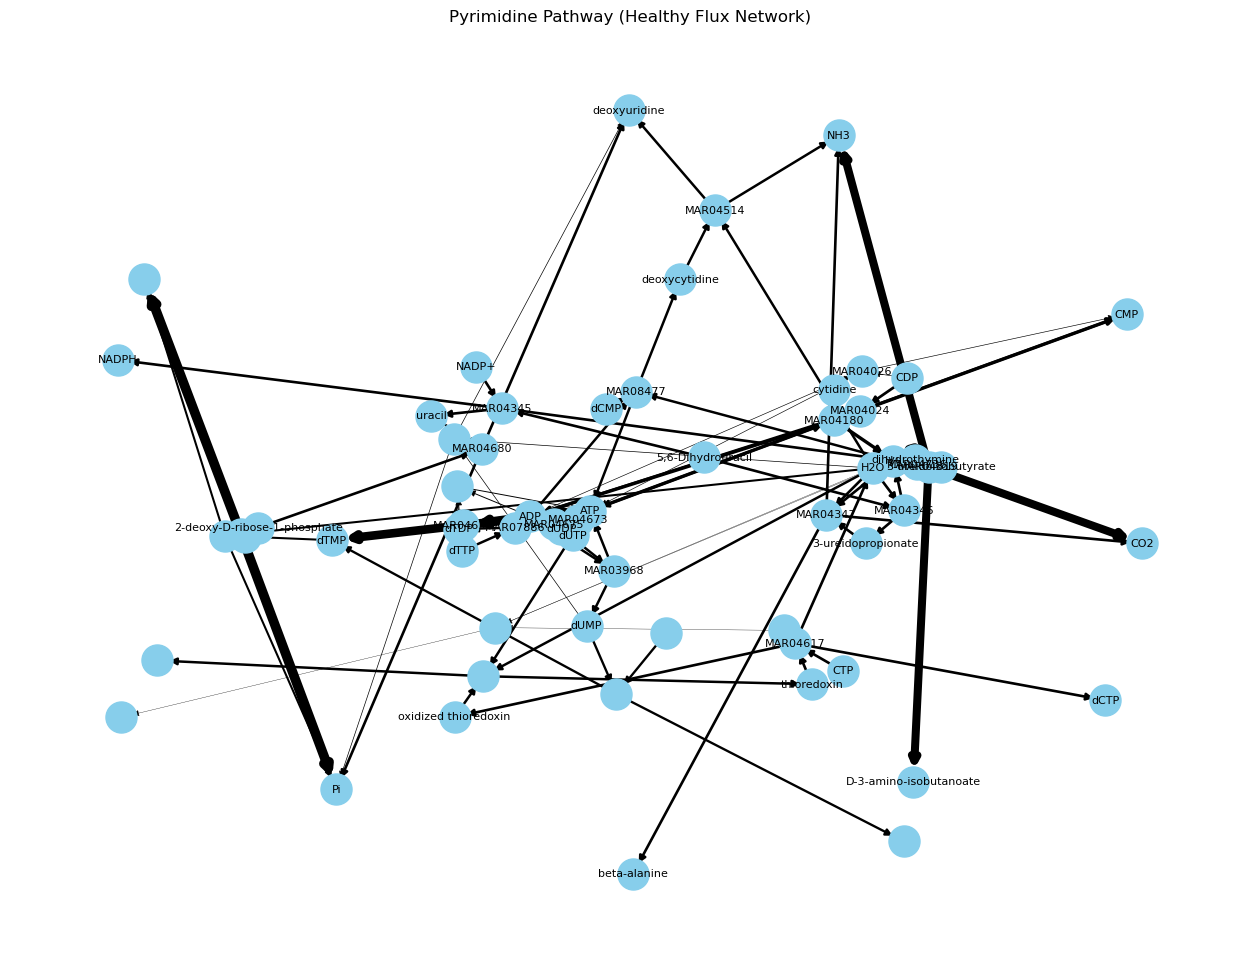

In [194]:
import numpy as np

plt.figure(figsize=(16, 12))

# Layout
pos = nx.spring_layout(G, k=0.3)

# Scale edge weights by flux
weights = [np.log1p(G[u][v]['weight']) for u, v in G.edges]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue")

# Draw edges with flux-based thickness
nx.draw_networkx_edges(G, pos, edge_color='black', width=weights, arrows=True)

# Draw labels (only a subset to avoid clutter)
limited_labels = {n: n for i, n in enumerate(G.nodes) if i < 50}
nx.draw_networkx_labels(G, pos, labels=limited_labels, font_size=8)

plt.title("Pyrimidine Pathway (Healthy Flux Network)")
plt.axis("off")
plt.show()

In [196]:
# Export for cytoscape
for rxn_id in pyrimidine_mar_ids:
    flux = pyrimidine_flux_df.loc[rxn_id, "tumor"]
    G.nodes[rxn_id]["type"] = "reaction"
    G.nodes[rxn_id]["flux"] = flux

    rxn = full_model.reactions.get_by_id(rxn_id)
    for met, coeff in rxn.metabolites.items():
        G.nodes[met.name]["type"] = "metabolite"

nx.write_graphml(G, "healthy_pyrimidine_flux.graphml")

### Pyrimidine Metabolism graph for tumor tissue 

In [199]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize graph
G = nx.DiGraph()

# Only use reactions with nonzero healthy flux
pyrimidine_mar_ids = pyrimidine_flux_df[pyrimidine_flux_df["tumor"] != 0].index


# Loop through reactions in pyrimidine set
for rxn_id in pyrimidine_mar_ids:
    rxn = full_model.reactions.get_by_id(rxn_id)
    flux = pyrimidine_flux_df.loc[rxn_id, "tumor"]

    # Add edges from metabolites to reaction (reactants)
    for met, coeff in rxn.metabolites.items():
        if coeff < 0:  # Reactant
            G.add_edge(met.name, rxn.id, weight=abs(flux))

        elif coeff > 0:  # Product
            G.add_edge(rxn.id, met.name, weight=abs(flux))

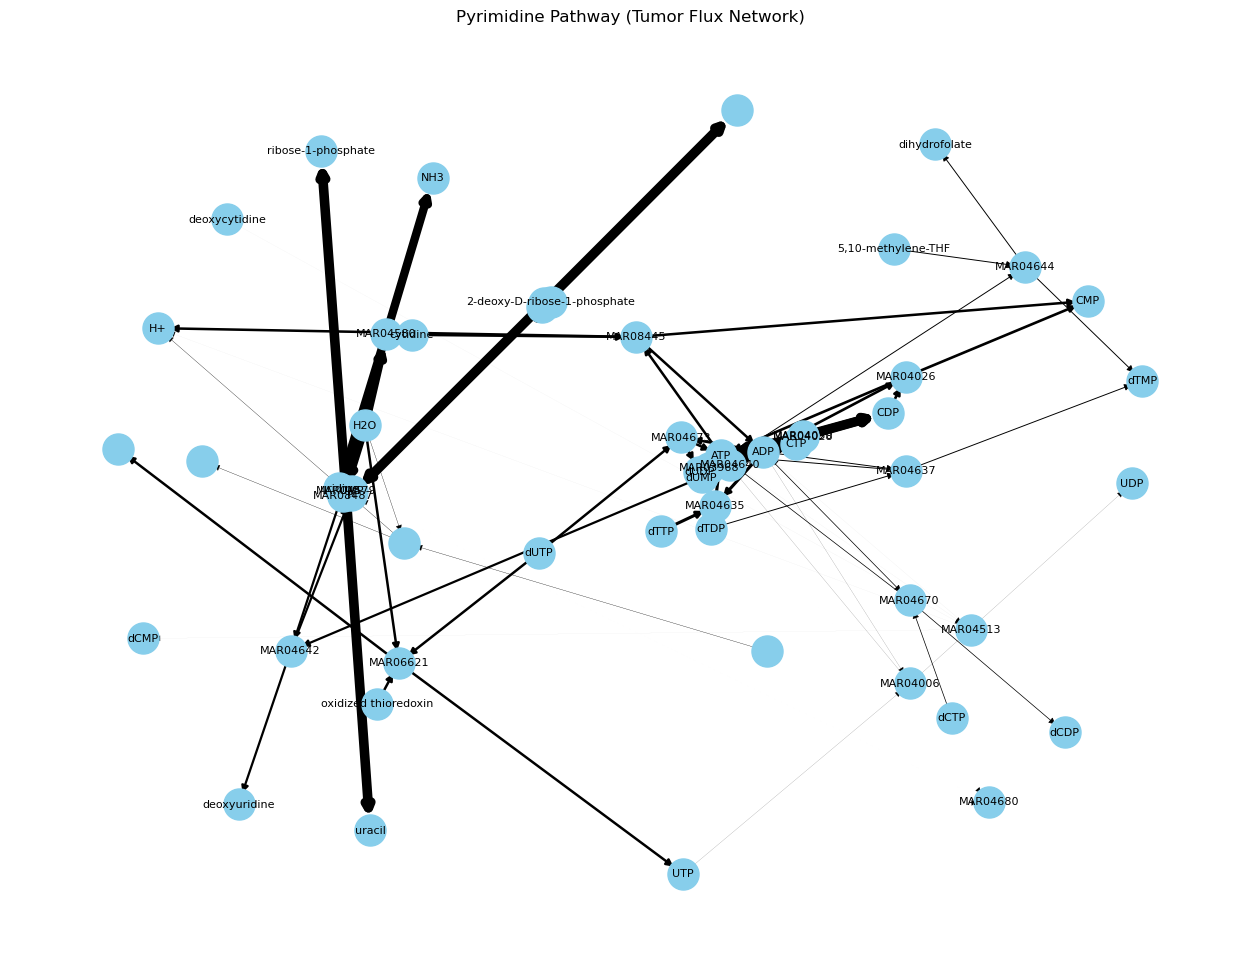

In [201]:
import numpy as np

plt.figure(figsize=(16, 12))

# Layout
pos = nx.spring_layout(G, k=0.3)

# Scale edge weights by flux
weights = [np.log1p(G[u][v]['weight']) for u, v in G.edges]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue")

# Draw edges with flux-based thickness
nx.draw_networkx_edges(G, pos, edge_color='black', width=weights, arrows=True)

# Draw labels (only a subset to avoid clutter)
limited_labels = {n: n for i, n in enumerate(G.nodes) if i < 50}
nx.draw_networkx_labels(G, pos, labels=limited_labels, font_size=8)

plt.title("Pyrimidine Pathway (Tumor Flux Network)")
plt.axis("off")
plt.show()

In [203]:
# Export for cytoscape
for rxn_id in pyrimidine_mar_ids:
    flux = pyrimidine_flux_df.loc[rxn_id, "tumor"]
    G.nodes[rxn_id]["type"] = "reaction"
    G.nodes[rxn_id]["flux"] = flux

    rxn = full_model.reactions.get_by_id(rxn_id)
    for met, coeff in rxn.metabolites.items():
        G.nodes[met.name]["type"] = "metabolite"

In [205]:
nx.write_graphml(G, "tumor_pyrimidine_flux.graphml")